# χ行列の主要エラー要素 vs 平均フォノン数

理想MSゲートを取り除いた post-gate error channel
$\mathcal{N}_{\mathrm{post}}=\mathcal{E}_{\mathrm{actual}}\circ\mathcal{U}_{\mathrm{ideal}}^\dagger$ のχ行列を $\mathrm{Tr}(\chi)=1$ に規格化し、主要成分
$\chi_{XX,XX}$ と $|\chi_{II,XX}|$ を $\bar n=0.01$ から20まで解析します。

- Pauli順序: `II, IX, IY, IZ, XI, XX, ... , ZZ`
- `II,XX` は複素成分なので、比較用の主量には絶対値を使います。厳密再計算時は実部・虚部も保存します。
- フィットは $\bar n=0.01$ のデータ点を必ず通る多項式です。既定は4次で、1〜5次の指標も比較します。
- 式は **0.01〜20の範囲内の経験式** です。範囲外への外挿には使わないでください。

初期状態では既存の81点QPT結果をキャッシュから読み、すぐに図と式を再生成します。`RECOMPUTE = True` にすると、各点を逐次再計算してCSVを安全に更新します。

In [2]:
from pathlib import Path
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import ms_gate_functions as mg
mg = importlib.reload(mg)

OUTPUT_DIR = Path("results/chi_error_element_fit")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = OUTPUT_DIR / "chi_error_element_sweep.csv"

NBAR_GRID = np.r_[0.01, np.arange(0.25, 20.0001, 0.25)]
RECOMPUTE = False          # True: 81点を厳密再計算し、途中結果を逐次保存
PARALLEL_WORKERS = 4       # 過大な並列数はメモリを圧迫するため控えめにする
FIT_DEGREE = 4
ERROR_CHANNEL_CONVENTION = "undo_before_actual"

print(f"Sweep points: {len(NBAR_GRID)} ({NBAR_GRID[0]} ... {NBAR_GRID[-1]})")
print(f"Cache: {CACHE_PATH}")
print(f"RECOMPUTE = {RECOMPUTE}")

Sweep points: 81 (0.01 ... 20.0)
Cache: results/chi_error_element_fit/chi_error_element_sweep.csv
RECOMPUTE = False


## シミュレーション設定

`main.ipynb` の現在の基準条件を明示的に固定しています。再計算は高い $\bar n$ ほどフォノン空間が大きくなり時間がかかるため、1点ごとにCSVへ保存します。中断後は同じセルを再実行すれば、`direct_simulation` になっている点を飛ばして続行できます。

In [3]:
SIMULATION_PARAMS = {
    "A": 0.125,
    "delta": 0.5,
    "rho0": 0.0,
    "time_points": 500,
    "t_gate_phys": 100e-6,
    "heating_rate_phys": 10.0,
    "dephasing_rate_phys": 18.0,
    "T2_star": 0.3,
    "rayleigh_rate_phys": 3.0,
    "raman_rate_phys": 1.0,
    "eta": 0.1,
    "laser_intensity_fluctuation": 0.0,
    "laser_detuning_fluctuation": 0.0,
    "laser_rotation_angle_fluctuation": 0.0,
    "laser_noise_samples": 1,
    "laser_noise_seed": 1234,
    "use_full_order": True,
    "show_progress": True,
    "parallel_workers": PARALLEL_WORKERS,
}
pd.Series(SIMULATION_PARAMS, name="value").to_frame()

,value
A,0.125
delta,0.5
rho0,0.0
time_points,500
t_gate_phys,0.0001
heating_rate_phys,10.0
dephasing_rate_phys,18.0
T2_star,0.3
rayleigh_rate_phys,3.0
raman_rate_phys,1.0


In [4]:
PAULI_LABELS = [label for label, _ in mg.pauli_labels_and_weights()]
II_INDEX = PAULI_LABELS.index("II")
XX_INDEX = PAULI_LABELS.index("XX")

def _trace_normalized_error_chi(n_bar):
    point_params = dict(SIMULATION_PARAMS)
    point_params["n_bar_list"] = [float(n_bar)]
    channel_result = mg.generate_chi_matrices(**point_params)
    error_result = mg.generate_error_channel_matrices(
        channel_result=channel_result,
        convention=ERROR_CHANNEL_CONVENTION,
    )
    chi = np.asarray(error_result["error_chi_matrix_list"][0], dtype=complex)
    trace = np.trace(chi)
    if abs(trace) < 1e-15:
        raise ValueError(f"n_bar={n_bar}: chi trace is too close to zero")
    return chi / trace

def simulate_target_elements(n_bar):
    chi = _trace_normalized_error_chi(n_bar)
    xx_xx = chi[XX_INDEX, XX_INDEX]
    ii_xx = chi[II_INDEX, XX_INDEX]
    if abs(np.imag(xx_xx)) > 1e-10:
        warnings.warn(f"n_bar={n_bar}: chi[XX,XX] has Im={np.imag(xx_xx):.3e}")
    return {
        "n_bar": float(n_bar),
        "chi_XX_XX": float(np.real(xx_xx)),
        "chi_II_XX_real": float(np.real(ii_xx)),
        "chi_II_XX_imag": float(np.imag(ii_xx)),
        "chi_II_XX_abs": float(abs(ii_xx)),
        "data_source": "direct_simulation",
    }

def _atomic_save_csv(frame, path):
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    frame.sort_values("n_bar").to_csv(temporary_path, index=False)
    temporary_path.replace(path)

def load_or_recompute_sweep():
    if CACHE_PATH.exists():
        frame = pd.read_csv(CACHE_PATH)
    else:
        frame = pd.DataFrame(columns=[
            "n_bar", "chi_XX_XX", "chi_II_XX_real",
            "chi_II_XX_imag", "chi_II_XX_abs", "data_source",
        ])

    if RECOMPUTE:
        for point_index, n_bar in enumerate(NBAR_GRID, start=1):
            exact_mask = (
                np.isclose(frame.get("n_bar", pd.Series(dtype=float)), n_bar)
                & frame.get("data_source", pd.Series(dtype=str)).eq("direct_simulation")
            )
            if exact_mask.any():
                print(f"[{point_index:02d}/{len(NBAR_GRID)}] n_bar={n_bar:g}: cached exact result")
                continue
            print(f"[{point_index:02d}/{len(NBAR_GRID)}] n_bar={n_bar:g}: simulating")
            row = simulate_target_elements(n_bar)
            frame = frame.loc[~np.isclose(frame["n_bar"].astype(float), n_bar)]
            frame = pd.concat([frame, pd.DataFrame([row])], ignore_index=True)
            _atomic_save_csv(frame, CACHE_PATH)

    if frame.empty:
        raise FileNotFoundError(
            f"No cached data at {CACHE_PATH}. Set RECOMPUTE=True and rerun this cell."
        )

    frame = frame.sort_values("n_bar").reset_index(drop=True)
    missing = [
        float(n_bar) for n_bar in NBAR_GRID
        if not np.isclose(frame["n_bar"].astype(float), n_bar).any()
    ]
    if missing:
        raise ValueError(f"Sweep cache is missing n_bar points: {missing}")
    return frame

sweep_df = load_or_recompute_sweep()
print(sweep_df["data_source"].value_counts().to_string())
display(sweep_df.head())
display(sweep_df.tail())

data_source
historical_qpt_and_heatmap_recovery    68
direct_simulation                      13


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
0,0.01,0.000353,-0.000524,0.013702,0.013712,direct_simulation
1,0.25,0.000537,-0.000652,0.017362,0.017375,direct_simulation
2,0.50,0.000784,-0.000783,0.021154,0.021168,direct_simulation
3,0.75,0.001086,-0.000912,0.024922,0.024938,direct_simulation
4,1.00,0.001443,-0.001040,0.028665,0.028684,direct_simulation


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
76,19.00,0.101549,NaN,NaN,0.219040,historical_qpt_and_heatmap_recovery
77,19.25,0.103312,NaN,NaN,0.220705,historical_qpt_and_heatmap_recovery
78,19.50,0.105075,NaN,NaN,0.222373,historical_qpt_and_heatmap_recovery
79,19.75,0.106836,NaN,NaN,0.223960,historical_qpt_and_heatmap_recovery
80,20.00,0.108596,NaN,NaN,0.225531,historical_qpt_and_heatmap_recovery


### キャッシュ精度について

`historical_qpt_and_heatmap_recovery` のうち $\chi_{XX,XX}$ は既存QPTの数値CSV、$|\chi_{II,XX}|$ は同じQPTから生成済みのχヒートマップのカラーバーから復元した値です。そのため後者は図の解像度相当（概ね $10^{-4}$ 以下）の復元誤差を含みます。論文値など高精度が必要な場合は `RECOMPUTE=True` で直接値に置き換えてください。

In [5]:
def anchored_polynomial_fit(x, y, degree):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(x)
    x, y = x[order], y[order]
    x0, y0 = float(x[0]), float(y[0])
    u = x - x0
    design = np.column_stack([u ** power for power in range(1, degree + 1)])
    coefficients = np.linalg.lstsq(design, y - y0, rcond=None)[0]

    def predict(x_new):
        shifted = np.asarray(x_new, dtype=float) - x0
        result = np.full_like(shifted, y0, dtype=float)
        for power, coefficient in enumerate(coefficients, start=1):
            result += coefficient * shifted ** power
        return result

    fitted = predict(x)
    residual = y - fitted
    ss_res = float(np.sum(residual ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r_squared = 1.0 - ss_res / ss_tot
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    max_abs_residual = float(np.max(np.abs(residual)))

    terms = [f"{y0:.8e}"]
    for power, coefficient in enumerate(coefficients, start=1):
        sign = "+" if coefficient >= 0 else "-"
        terms.append(f" {sign} {abs(coefficient):.8e}(n-0.01)^{power}")
    equation = "y(n) = " + "".join(terms)
    return {
        "degree": int(degree), "x0": x0, "y0": y0,
        "coefficients": coefficients, "predict": predict,
        "fitted": fitted, "residual": residual,
        "r_squared": r_squared, "rmse": rmse,
        "max_abs_residual": max_abs_residual, "equation": equation,
    }

x_data = sweep_df["n_bar"].to_numpy(float)
FIT_TARGETS = {
    r"$\chi_{XX,XX}$": "chi_XX_XX",
    r"$|\chi_{II,XX}|$": "chi_II_XX_abs",
}

diagnostic_rows = []
for label, column in FIT_TARGETS.items():
    for degree in range(1, 6):
        fit = anchored_polynomial_fit(x_data, sweep_df[column], degree)
        diagnostic_rows.append({
            "element": label.replace("$", ""),
            "degree": degree,
            "R_squared": fit["r_squared"],
            "RMSE": fit["rmse"],
            "max_abs_residual": fit["max_abs_residual"],
        })
fit_diagnostics_df = pd.DataFrame(diagnostic_rows)
display(fit_diagnostics_df)

,element,degree,R_squared,RMSE,max_abs_residual
0,"\chi_{XX,XX}",1,0.946932,0.007761,0.012785
1,"\chi_{XX,XX}",2,0.997520,0.001678,0.003694
2,"\chi_{XX,XX}",3,0.999973,0.000174,0.000442
3,"\chi_{XX,XX}",4,1.000000,0.000007,0.000022
4,"\chi_{XX,XX}",5,1.000000,0.000003,0.000009
5,"|\chi_{II,XX}|",1,0.968907,0.010939,0.022797
6,"|\chi_{II,XX}|",2,0.999972,0.000328,0.000981
7,"|\chi_{II,XX}|",3,0.999994,0.000154,0.000307
8,"|\chi_{II,XX}|",4,0.999999,0.000052,0.000127
9,"|\chi_{II,XX}|",5,1.000000,0.000026,0.000088


In [6]:
selected_fits = {
    column: anchored_polynomial_fit(x_data, sweep_df[column], FIT_DEGREE)
    for column in FIT_TARGETS.values()
}

summary_rows = []
for label, column in FIT_TARGETS.items():
    fit = selected_fits[column]
    row = {
        "element": label.replace("$", ""),
        "degree": fit["degree"],
        "n_bar_anchor": fit["x0"],
        "value_at_anchor": fit["y0"],
        "R_squared": fit["r_squared"],
        "RMSE": fit["rmse"],
        "max_abs_residual": fit["max_abs_residual"],
        "equation": fit["equation"],
    }
    for power, coefficient in enumerate(fit["coefficients"], start=1):
        row[f"a{power}"] = coefficient
    summary_rows.append(row)

fit_summary_df = pd.DataFrame(summary_rows)
fit_summary_path = OUTPUT_DIR / "chi_error_element_fit_summary.csv"
fit_summary_df.to_csv(fit_summary_path, index=False)
display(fit_summary_df)

for _, row in fit_summary_df.iterrows():
    display(Markdown(
        f"**{row['element']}**: `{row['equation']}`<br>"
        f"$R^2={row['R_squared']:.8f}$, RMSE = {row['RMSE']:.3e}"
    ))
print(f"Saved: {fit_summary_path}")

,element,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"\chi_{XX,XX}",4,0.01,0.000353,1.000000,0.000007,0.000022,y(n) = 3.52629218e-04 + 6.58124566e-04(n-0.01)...,0.000658,0.000465,-0.000015,1.788960e-07
1,"|\chi_{II,XX}|",4,0.01,0.013712,0.999999,0.000052,0.000127,y(n) = 1.37116490e-02 + 1.54084907e-02(n-0.01)...,0.015408,-0.000216,-0.000004,1.492305e-07


**\chi_{XX,XX}**: `y(n) = 3.52629218e-04 + 6.58124566e-04(n-0.01)^1 + 4.64640112e-04(n-0.01)^2 - 1.49132880e-05(n-0.01)^3 + 1.78896022e-07(n-0.01)^4`<br>$R^2=0.99999996$, RMSE = 6.598e-06

**|\chi_{II,XX}|**: `y(n) = 1.37116490e-02 + 1.54084907e-02(n-0.01)^1 - 2.15925245e-04(n-0.01)^2 - 4.20845038e-06(n-0.01)^3 + 1.49230466e-07(n-0.01)^4`<br>$R^2=0.99999930$, RMSE = 5.188e-05

Saved: results/chi_error_element_fit/chi_error_element_fit_summary.csv


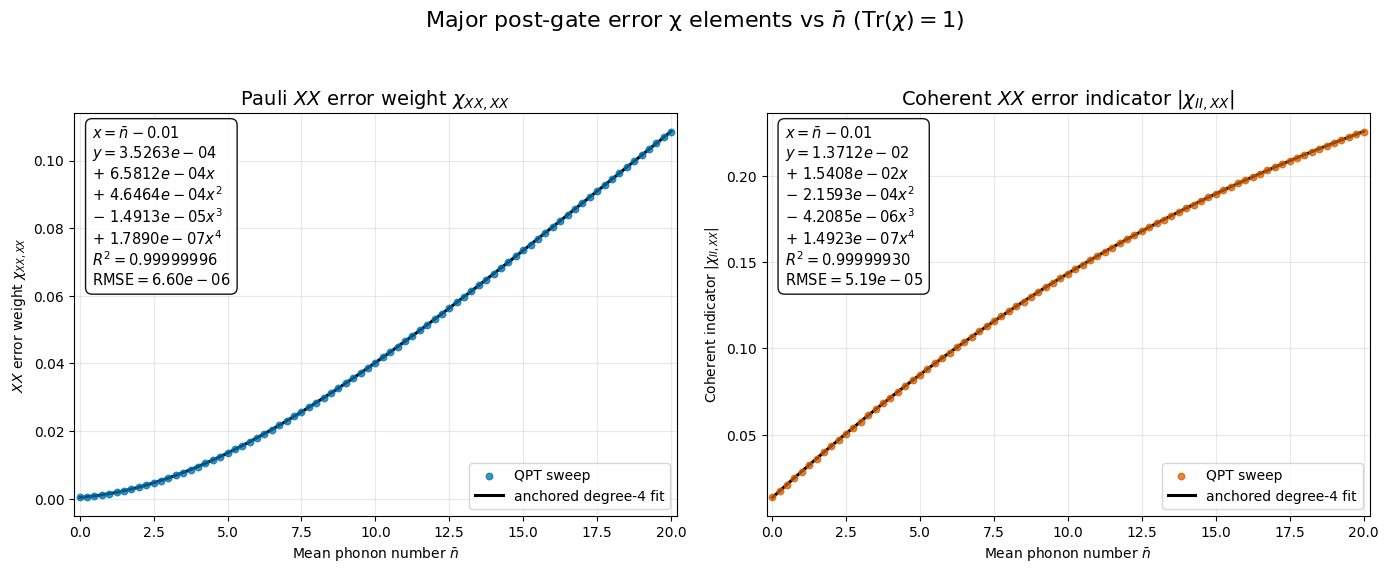

Saved: results/chi_error_element_fit/chi_error_elements_vs_nbar_fit.png
Saved: results/chi_error_element_fit/chi_error_elements_vs_nbar_fit.pdf
Saved: results/chi_error_element_fit/chi_error_element_fit_curves.csv


In [7]:
x_dense = np.linspace(NBAR_GRID.min(), NBAR_GRID.max(), 1000)
colors = {"chi_XX_XX": "#0072B2", "chi_II_XX_abs": "#D55E00"}
titles = {
    "chi_XX_XX": r"Pauli $XX$ error weight $\chi_{XX,XX}$",
    "chi_II_XX_abs": r"Coherent $XX$ error indicator $|\chi_{II,XX}|$",
}
y_labels = {
    "chi_XX_XX": r"$XX$ error weight $\chi_{XX,XX}$",
    "chi_II_XX_abs": r"Coherent indicator $|\chi_{II,XX}|$",
}

def equation_text(fit):
    lines = [r"$x=\bar n-0.01$", rf"$y={fit['y0']:.4e}$"]
    for power, coefficient in enumerate(fit["coefficients"], start=1):
        sign = "+" if coefficient >= 0 else "-"
        exponent = "" if power == 1 else f"^{{{power}}}"
        lines.append(rf"${sign}\ {abs(coefficient):.4e}x{exponent}$")
    lines.append(rf"$R^2={fit['r_squared']:.8f}$")
    lines.append(rf"$\mathrm{{RMSE}}={fit['rmse']:.2e}$")
    return chr(10).join(lines)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.8))
for column_index, column in enumerate(FIT_TARGETS.values()):
    fit = selected_fits[column]
    color = colors[column]
    y_data = sweep_df[column].to_numpy(float)
    ax = axes[column_index]
    ax.scatter(
        x_data, y_data, s=22, color=color, alpha=0.75, label="QPT sweep", zorder=3
    )
    ax.plot(
        x_dense, fit["predict"](x_dense), color="black", linewidth=2.2,
        label=f"anchored degree-{FIT_DEGREE} fit",
    )
    ax.set_title(titles[column], fontsize=14)
    ax.set_xlabel(r"Mean phonon number $\bar n$")
    ax.set_ylabel(y_labels[column])
    ax.legend(frameon=True, loc="lower right")
    ax.text(
        0.03, 0.97, equation_text(fit),
        transform=ax.transAxes, va="top", ha="left", fontsize=10.5,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "alpha": 0.92},
    )

for ax in axes.ravel():
    ax.grid(True, alpha=0.28)
    ax.set_xlim(NBAR_GRID.min() - 0.2, NBAR_GRID.max() + 0.2)

fig.suptitle(
    r"Major post-gate error χ elements vs $\bar n$ ($\mathrm{Tr}(\chi)=1$)",
    fontsize=16,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
figure_png = OUTPUT_DIR / "chi_error_elements_vs_nbar_fit.png"
figure_pdf = OUTPUT_DIR / "chi_error_elements_vs_nbar_fit.pdf"
fig.savefig(figure_png, dpi=300, bbox_inches="tight")
fig.savefig(figure_pdf, bbox_inches="tight")
plt.show()

prediction_df = pd.DataFrame({"n_bar": x_dense})
for column, fit in selected_fits.items():
    prediction_df[f"{column}_fit"] = fit["predict"](x_dense)
prediction_path = OUTPUT_DIR / "chi_error_element_fit_curves.csv"
prediction_df.to_csv(prediction_path, index=False)
print(f"Saved: {figure_png}")
print(f"Saved: {figure_pdf}")
print(f"Saved: {prediction_path}")

In [8]:
# RECOMPUTE=True で直接計算した場合のみ、II,XX の複素成分も確認する。
complex_columns = ["chi_II_XX_real", "chi_II_XX_imag"]
if sweep_df[complex_columns].notna().all().all():
    fig_complex, ax_complex = plt.subplots(figsize=(7.5, 4.7))
    ax_complex.plot(sweep_df["n_bar"], sweep_df["chi_II_XX_real"], label=r"$\Re\chi_{II,XX}$")
    ax_complex.plot(sweep_df["n_bar"], sweep_df["chi_II_XX_imag"], label=r"$\Im\chi_{II,XX}$")
    ax_complex.plot(sweep_df["n_bar"], sweep_df["chi_II_XX_abs"], label=r"$|\chi_{II,XX}|$", linewidth=2.2)
    ax_complex.set_xlabel(r"Mean phonon number $\bar n$")
    ax_complex.set_ylabel("Trace-normalized χ element")
    ax_complex.grid(True, alpha=0.3)
    ax_complex.legend()
    fig_complex.tight_layout()
    complex_path = OUTPUT_DIR / "chi_II_XX_complex_components.png"
    fig_complex.savefig(complex_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {complex_path}")
else:
    print("Complex II,XX components are not in the recovered cache. Set RECOMPUTE=True for direct values.")

Complex II,XX components are not in the recovered cache. Set RECOMPUTE=True for direct values.


## その他の主要なχ対角ノイズ

既存81点QPTの全Pauli対角成分を順位付けします。`II`（無誤差）と上で解析済みの `XX` を除き、区間内最大値が $\chi_{XX,XX}$ の最大値の1%以上となる成分を「その他の主要ノイズ」とします。選ばれた各成分に、上と同じ端点固定4次最小二乗フィットを適用します。

In [9]:
PAULI_DIAGONAL_CACHE_PATH = Path("pauli_twirled_error_probabilities.zip")
MAJOR_OTHER_RELATIVE_THRESHOLD = 0.01

pauli_long_df = pd.read_csv(PAULI_DIAGONAL_CACHE_PATH, compression="zip")
required_pauli_columns = {"n_bar", "pauli", "probability"}
if not required_pauli_columns.issubset(pauli_long_df.columns):
    raise ValueError(f"Pauli cache must contain {sorted(required_pauli_columns)}")
pauli_wide_df = (
    pauli_long_df.pivot(index="n_bar", columns="pauli", values="probability")
    .sort_index()
)
missing_pauli_points = [
    float(n_bar) for n_bar in NBAR_GRID
    if not np.isclose(pauli_wide_df.index.to_numpy(float), n_bar).any()
]
if missing_pauli_points:
    raise ValueError(f"Pauli cache is missing n_bar points: {missing_pauli_points}")

xx_peak = float(pauli_wide_df["XX"].max())
ranking_rows = []
for pauli in PAULI_LABELS:
    values = pauli_wide_df[pauli].to_numpy(float)
    ranking_rows.append({
        "pauli": pauli,
        "max_over_sweep": float(np.max(values)),
        "value_at_nbar_0p01": float(values[0]),
        "value_at_nbar_20": float(values[-1]),
        "relative_to_XX_peak": float(np.max(values) / xx_peak),
    })
pauli_ranking_df = (
    pd.DataFrame(ranking_rows)
    .sort_values("max_over_sweep", ascending=False)
    .reset_index(drop=True)
)
other_ranking_df = pauli_ranking_df[~pauli_ranking_df["pauli"].isin(["II", "XX"])].copy()
OTHER_MAJOR_PAULIS = other_ranking_df.loc[
    other_ranking_df["relative_to_XX_peak"] >= MAJOR_OTHER_RELATIVE_THRESHOLD,
    "pauli",
].tolist()
if not OTHER_MAJOR_PAULIS:
    OTHER_MAJOR_PAULIS = other_ranking_df.head(2)["pauli"].tolist()

ranking_path = OUTPUT_DIR / "chi_pauli_diagonal_noise_ranking.csv"
pauli_ranking_df.to_csv(ranking_path, index=False)
print("Selected other major Pauli noises:", OTHER_MAJOR_PAULIS)
print(f"Selection threshold: {100 * MAJOR_OTHER_RELATIVE_THRESHOLD:.1f}% of max chi[XX,XX]")
display(other_ranking_df.head(12))
print(f"Saved: {ranking_path}")

Selected other major Pauli noises: ['IX', 'XI']
Selection threshold: 1.0% of max chi[XX,XX]


,pauli,max_over_sweep,value_at_nbar_0p01,value_at_nbar_20,relative_to_XX_peak
2,IX,6.792169e-03,5.489609e-04,6.792169e-03,0.062546
3,XI,6.792169e-03,5.489658e-04,6.792169e-03,0.062546
4,IZ,1.742226e-04,1.742226e-04,1.307732e-04,0.001604
5,ZI,1.742221e-04,1.742221e-04,1.307772e-04,0.001604
6,YX,1.742133e-04,1.742133e-04,1.306923e-04,0.001604
7,XY,1.742125e-04,1.742125e-04,1.306950e-04,0.001604
8,IY,1.149983e-04,7.137986e-05,1.149909e-04,0.001059
9,YI,1.149873e-04,7.138454e-05,1.149873e-04,0.001059
10,ZX,1.147266e-04,7.136353e-05,1.147266e-04,0.001056
11,XZ,1.147244e-04,7.136854e-05,1.147244e-04,0.001056


Saved: results/chi_error_element_fit/chi_pauli_diagonal_noise_ranking.csv


,element,pauli,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"chi_{IX,IX}",IX,4,0.01,0.000549,1.0,8.403856e-07,0.000004,y(n) = 5.48960862e-04 + 5.35969980e-04(n-0.01)...,0.000536,-0.000016,3.219822e-07,-3.759491e-09
1,"chi_{XI,XI}",XI,4,0.01,0.000549,1.0,8.423585e-07,0.000004,y(n) = 5.48965783e-04 + 5.35964832e-04(n-0.01)...,0.000536,-0.000016,3.219415e-07,-3.758916e-09


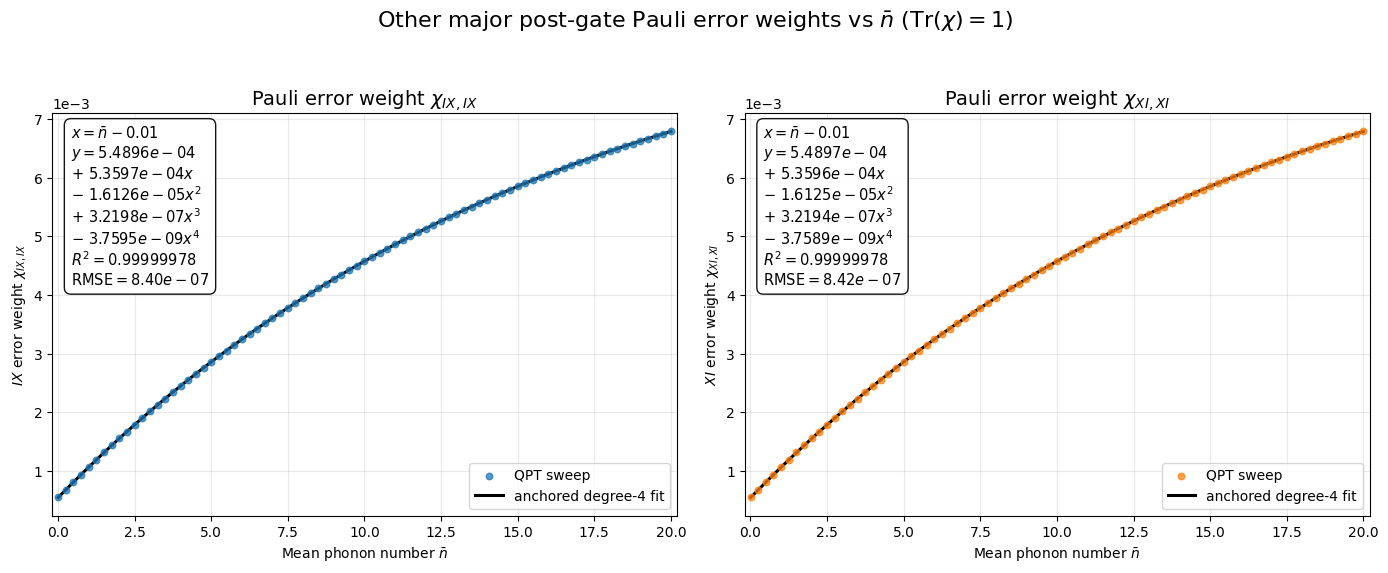

Saved: results/chi_error_element_fit/chi_other_major_noise_fit_summary.csv
Saved: results/chi_error_element_fit/chi_other_major_noise_vs_nbar_fit.png
Saved: results/chi_error_element_fit/chi_other_major_noise_vs_nbar_fit.pdf
Saved: results/chi_error_element_fit/chi_other_major_noise_fit_curves.csv


In [10]:
other_x_data = pauli_wide_df.index.to_numpy(float)
other_noise_fits = {
    pauli: anchored_polynomial_fit(other_x_data, pauli_wide_df[pauli], FIT_DEGREE)
    for pauli in OTHER_MAJOR_PAULIS
}

other_summary_rows = []
for pauli, fit in other_noise_fits.items():
    row = {
        "element": f"chi_{{{pauli},{pauli}}}",
        "pauli": pauli,
        "degree": fit["degree"],
        "n_bar_anchor": fit["x0"],
        "value_at_anchor": fit["y0"],
        "R_squared": fit["r_squared"],
        "RMSE": fit["rmse"],
        "max_abs_residual": fit["max_abs_residual"],
        "equation": fit["equation"],
    }
    for power, coefficient in enumerate(fit["coefficients"], start=1):
        row[f"a{power}"] = coefficient
    other_summary_rows.append(row)
other_fit_summary_df = pd.DataFrame(other_summary_rows)
other_summary_path = OUTPUT_DIR / "chi_other_major_noise_fit_summary.csv"
other_fit_summary_df.to_csv(other_summary_path, index=False)
display(other_fit_summary_df)

n_other = len(OTHER_MAJOR_PAULIS)
fig_other, axes_other = plt.subplots(1, n_other, figsize=(7.0 * n_other, 5.8), squeeze=False)
axes_other = axes_other.ravel()
other_colors = plt.get_cmap("tab10").colors
for panel_index, pauli in enumerate(OTHER_MAJOR_PAULIS):
    ax = axes_other[panel_index]
    fit = other_noise_fits[pauli]
    y_values = pauli_wide_df[pauli].to_numpy(float)
    color = other_colors[panel_index % len(other_colors)]
    ax.scatter(other_x_data, y_values, s=22, color=color, alpha=0.75, label="QPT sweep", zorder=3)
    ax.plot(x_dense, fit["predict"](x_dense), color="black", linewidth=2.2, label=f"anchored degree-{FIT_DEGREE} fit")
    ax.set_title(rf"Pauli error weight $\chi_{{{pauli},{pauli}}}$", fontsize=14)
    ax.set_xlabel(r"Mean phonon number $\bar n$")
    ax.set_ylabel(rf"${pauli}$ error weight $\chi_{{{pauli},{pauli}}}$")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
    ax.set_xlim(NBAR_GRID.min() - 0.2, NBAR_GRID.max() + 0.2)
    ax.grid(True, alpha=0.28)
    ax.legend(frameon=True, loc="lower right")
    ax.text(
        0.03, 0.97, equation_text(fit),
        transform=ax.transAxes, va="top", ha="left", fontsize=10.5,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "alpha": 0.92},
    )

fig_other.suptitle(
    r"Other major post-gate Pauli error weights vs $\bar n$ ($\mathrm{Tr}(\chi)=1$)",
    fontsize=16,
)
fig_other.tight_layout(rect=(0, 0, 1, 0.94))
other_figure_png = OUTPUT_DIR / "chi_other_major_noise_vs_nbar_fit.png"
other_figure_pdf = OUTPUT_DIR / "chi_other_major_noise_vs_nbar_fit.pdf"
fig_other.savefig(other_figure_png, dpi=300, bbox_inches="tight")
fig_other.savefig(other_figure_pdf, bbox_inches="tight")
plt.show()

other_prediction_df = pd.DataFrame({"n_bar": x_dense})
for pauli, fit in other_noise_fits.items():
    other_prediction_df[f"chi_{pauli}_{pauli}_fit"] = fit["predict"](x_dense)
other_prediction_path = OUTPUT_DIR / "chi_other_major_noise_fit_curves.csv"
other_prediction_df.to_csv(other_prediction_path, index=False)
print(f"Saved: {other_summary_path}")
print(f"Saved: {other_figure_png}")
print(f"Saved: {other_figure_pdf}")
print(f"Saved: {other_prediction_path}")

### その他の主要ノイズの読み方

この基準では `IX` と `XI` が選ばれます。$\chi_{IX,IX}$ は第2イオン、$\chi_{XI,XI}$ は第1イオンに作用する単一量子ビット $X$ エラーの重みです。2本がほぼ一致することは、2イオンにほぼ対称なノイズが作用していることを示します。次点以下の対角成分は、区間内最大でも $\chi_{XX,XX}$ 最大値の約0.16%以下です。

## 論文化に向けた最低限の検証コード

以下は、(1) 生の複素χ行列の直接保存、(2) 数値収束試験、(3) ノイズ源アブレーション、(4) 全256成分の順位付け、(5) モデル比較・交差検証・信頼区間、(6) 再現性情報の保存を行います。重いQPT計算は誤実行を防ぐため既定で無効です。スイッチを1つずつ `True` にし、上から順に実行してください。

In [11]:
import json
import platform
import subprocess
from contextlib import contextmanager

import matplotlib
import qutip as qp
import scipy

RUN_EXACT_FULL_CHI_SWEEP = True
RUN_NUMERICAL_CONVERGENCE = True
RUN_NOISE_SOURCE_ABLATION = True
FORCE_RECOMPUTE_PUBLICATION_CACHE = False

EXACT_FULL_CHI_DIR = OUTPUT_DIR / "exact_full_chi"
CONVERGENCE_DIR = OUTPUT_DIR / "numerical_convergence"
ABLATION_DIR = OUTPUT_DIR / "noise_source_ablation"
for directory in (EXACT_FULL_CHI_DIR, CONVERGENCE_DIR, ABLATION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CONVERGENCE_NBARS = [0.01, 4.0, 20.0]
ABLATION_NBARS = [0.01, 1.0, 4.0, 10.0, 20.0]
NOISE_SOURCES = [
    "motional_heating", "motional_dephasing",
    "spin_dephasing", "photon_scattering",
]
FULL_CHI_TOP_K = 12
BOOTSTRAP_SAMPLES = 1000
BOOTSTRAP_SEED = 20260805

print("Heavy publication checks:")
print(" exact full chi sweep =", RUN_EXACT_FULL_CHI_SWEEP)
print(" numerical convergence =", RUN_NUMERICAL_CONVERGENCE)
print(" noise-source ablation =", RUN_NOISE_SOURCE_ABLATION)

Heavy publication checks:
 exact full chi sweep = True
 numerical convergence = True
 noise-source ablation = True


### 1. 81点の生の複素χ行列を直接保存

`RUN_EXACT_FULL_CHI_SWEEP=True` で実行します。各 $\bar n$ の16×16複素χ行列を画像ではなくNPZへ直接保存し、同時にCP・TP、Hermiticity、規約、フォノン打ち切り次元を記録します。既に保存済みの点はスキップされます。

In [12]:
def _safe_nbar_stem(n_bar):
    return str(float(n_bar)).replace("-", "m").replace(".", "p")

def calculate_error_channel_point(n_bar, parameter_overrides=None):
    params = dict(SIMULATION_PARAMS)
    if parameter_overrides:
        params.update(parameter_overrides)
    params["n_bar_list"] = [float(n_bar)]
    error_result = mg.generate_error_channel_matrices(
        convention=ERROR_CHANNEL_CONVENTION,
        **params,
    )
    chi_raw = np.asarray(error_result["error_chi_matrix_list"][0], dtype=complex)
    raw_trace = np.trace(chi_raw)
    if abs(raw_trace) < 1e-15:
        raise ValueError(f"n_bar={n_bar}: raw chi trace is too close to zero")
    chi = chi_raw / raw_trace
    physicality = mg.choi_physicality_metrics(error_result["S_error_qobj_list"][0])
    composition = mg.validate_error_channel_composition(
        error_result, desired_convention=ERROR_CHANNEL_CONVENTION
    )
    metadata = {
        "n_bar": float(n_bar),
        "phonon_dim": int(error_result["results_list"][0]["Nv"]),
        "raw_trace_real": float(np.real(raw_trace)),
        "raw_trace_imag": float(np.imag(raw_trace)),
        "trace_normalized_hermiticity_fro": float(np.linalg.norm(chi - chi.conj().T)),
        "convention_error_fro": float(composition["max_desired_convention_error"]),
        **physicality,
    }
    return chi_raw, chi, metadata

def save_exact_full_chi_point(n_bar, chi_raw, chi, metadata):
    path = EXACT_FULL_CHI_DIR / f"error_chi_nbar_{_safe_nbar_stem(n_bar)}.npz"
    temporary_path = path.with_name(path.stem + ".tmp.npz")
    np.savez_compressed(
        temporary_path,
        n_bar=float(n_bar),
        chi_raw=chi_raw,
        chi_trace_normalized=chi,
        pauli_labels=np.asarray(PAULI_LABELS),
        metadata_json=json.dumps(metadata, default=str),
    )
    temporary_path.replace(path)
    return path

def update_target_cache_from_exact_chi(n_bar, chi):
    frame = pd.read_csv(CACHE_PATH) if CACHE_PATH.exists() else pd.DataFrame()
    ii_xx = chi[II_INDEX, XX_INDEX]
    row = {
        "n_bar": float(n_bar),
        "chi_XX_XX": float(np.real(chi[XX_INDEX, XX_INDEX])),
        "chi_II_XX_real": float(np.real(ii_xx)),
        "chi_II_XX_imag": float(np.imag(ii_xx)),
        "chi_II_XX_abs": float(abs(ii_xx)),
        "data_source": "direct_simulation",
    }
    if not frame.empty:
        frame = frame.loc[~np.isclose(frame["n_bar"].astype(float), float(n_bar))]
    frame = pd.concat([frame, pd.DataFrame([row])], ignore_index=True)
    _atomic_save_csv(frame, CACHE_PATH)

def load_exact_full_chi_points():
    points = []
    for path in EXACT_FULL_CHI_DIR.glob("error_chi_nbar_*.npz"):
        with np.load(path, allow_pickle=False) as data:
            points.append({
                "n_bar": float(data["n_bar"]),
                "chi": np.asarray(data["chi_trace_normalized"], dtype=complex),
                "path": path,
                "metadata": json.loads(str(data["metadata_json"])),
            })
    return sorted(points, key=lambda point: point["n_bar"])

exact_index_rows = []
if RUN_EXACT_FULL_CHI_SWEEP:
    for point_index, n_bar in enumerate(NBAR_GRID, start=1):
        output_path = EXACT_FULL_CHI_DIR / f"error_chi_nbar_{_safe_nbar_stem(n_bar)}.npz"
        if output_path.exists() and not FORCE_RECOMPUTE_PUBLICATION_CACHE:
            print(f"[{point_index:02d}/{len(NBAR_GRID)}] n_bar={n_bar:g}: cached")
            continue
        print(f"[{point_index:02d}/{len(NBAR_GRID)}] n_bar={n_bar:g}: exact QPT")
        chi_raw, chi, metadata = calculate_error_channel_point(n_bar)
        saved_path = save_exact_full_chi_point(n_bar, chi_raw, chi, metadata)
        update_target_cache_from_exact_chi(n_bar, chi)
        exact_index_rows.append({**metadata, "path": str(saved_path)})
        pd.DataFrame(exact_index_rows).to_csv(EXACT_FULL_CHI_DIR / "latest_run_index.csv", index=False)

exact_full_chi_points = load_exact_full_chi_points()
print(f"Exact full-chi cache: {len(exact_full_chi_points)}/{len(NBAR_GRID)} points")
if exact_full_chi_points:
    exact_metadata_df = pd.DataFrame([point["metadata"] for point in exact_full_chi_points])
    exact_metadata_df.to_csv(EXACT_FULL_CHI_DIR / "exact_full_chi_validation.csv", index=False)
    display(exact_metadata_df)

[01/81] n_bar=0.01: exact QPT
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
[02/81] n_bar=0.25: exact QPT
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.25 Simulation Finished (Dim: 21)
[03/81] n_bar=0.5: exact QPT
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.5 Simulation Finished (Dim: 22)
[04/81] n_bar=0.75: exact QPT
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.75 Simulation Finished (Dim: 23)
[05/81] n_bar=1: exact QPT
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 1.0 Simulation Finished (Dim: 25)
[06/81] n_bar=1.25: exact QPT
MS gate sim

,n_bar,phonon_dim,raw_trace_real,raw_trace_imag,trace_normalized_hermiticity_fro,convention_error_fro,dimension,choi_trace,expected_choi_trace_for_tp,choi_trace_error,tp_frobenius_error,tp_max_abs_error,min_choi_eigenvalue,negative_choi_eigenvalue_count,tp_pass,cp_pass
0,0.01,20,16.0,1.799442e-17,8.226611e-16,0.0,4,4.0,4,4.441120e-16,1.681932e-15,7.229287e-16,1.471214e-07,0,True,True
1,0.25,21,16.0,1.985790e-18,6.069958e-16,0.0,4,4.0,4,4.964476e-19,2.740699e-15,1.332274e-15,1.494379e-07,0,True,True
2,0.50,22,16.0,-2.433716e-17,5.477606e-16,0.0,4,4.0,4,6.084290e-18,1.991040e-15,9.281566e-16,1.420811e-07,0,True,True
3,0.75,23,16.0,6.855207e-18,4.378303e-16,0.0,4,4.0,4,1.713802e-18,2.008340e-15,7.771618e-16,1.823241e-07,0,True,True
4,1.00,25,16.0,2.000288e-17,5.075605e-16,0.0,4,4.0,4,4.441174e-16,2.288675e-15,8.881810e-16,1.429901e-07,0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,19.00,335,16.0,-3.857103e-18,2.477808e-16,0.0,4,4.0,4,2.664535e-15,9.018078e-15,4.440892e-15,-6.700579e-07,1,True,False
77,19.25,340,16.0,3.542461e-18,2.772767e-16,0.0,4,4.0,4,3.552714e-15,1.267060e-14,6.217249e-15,-6.877848e-07,1,True,False
78,19.50,345,16.0,-6.149587e-18,2.767528e-16,0.0,4,4.0,4,1.537406e-18,4.698263e-15,2.069290e-15,1.507784e-07,0,True,True
79,19.75,350,16.0,2.211852e-18,2.568161e-16,0.0,4,4.0,4,2.664535e-15,1.012739e-14,4.006352e-15,-1.492663e-06,1,True,False


### 2. 数値収束性（phonon cutoff・時間刻み・solver tolerance）

論文では、観測したχ成分が数値設定を厳しくしても変わらないことを示します。代表点 $\bar n=0.01,4,20$ で、基準設定に対するχ行列全体のFrobenius差と主要4成分の差を比較します。

`RUN_NUMERICAL_CONVERGENCE=True` にして実行すると、各条件を独立したNPZへ保存します。途中で停止しても、保存済み条件は再利用されます。

[01/12] baseline, n_bar=0.01: simulating
[02/12] phonon_cutoff_1p2x, n_bar=0.01: simulating
[03/12] time_grid_750, n_bar=0.01: simulating
[04/12] strict_solver_tol, n_bar=0.01: simulating
[05/12] baseline, n_bar=4: simulating
[06/12] phonon_cutoff_1p2x, n_bar=4: simulating
[07/12] time_grid_750, n_bar=4: simulating
[08/12] strict_solver_tol, n_bar=4: simulating
[09/12] baseline, n_bar=20: simulating
[10/12] phonon_cutoff_1p2x, n_bar=20: simulating
[11/12] time_grid_750, n_bar=20: simulating
[12/12] strict_solver_tol, n_bar=20: simulating


,n_bar,case,phonon_dim,time_points,solver_atol,solver_rtol,chi_frobenius_difference_from_baseline,delta_chi_XX_XX,delta_abs_chi_II_XX,delta_chi_IX_IX,delta_chi_XI_XI
0,0.01,baseline,20,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.01,phonon_cutoff_1p2x,24,500,1.000000e-12,1.000000e-09,1.410168e-07,9.710042e-09,1.165605e-08,7.880690e-09,-8.881181e-09
2,0.01,time_grid_750,20,750,1.000000e-12,1.000000e-09,1.582912e-05,-3.052450e-07,-1.117783e-05,1.166916e-08,5.758157e-09
3,0.01,strict_solver_tol,20,500,1.000000e-13,1.000000e-10,8.278577e-08,1.174198e-10,-1.357508e-08,3.024249e-09,-1.277186e-09
4,4.00,baseline,67,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,4.00,phonon_cutoff_1p2x,81,500,1.000000e-12,1.000000e-09,1.402904e-06,3.215637e-08,7.809372e-07,-2.203228e-07,-1.887032e-07
6,4.00,time_grid_750,67,750,1.000000e-12,1.000000e-09,1.466400e-05,-1.312070e-06,-1.027634e-05,-1.418031e-08,-2.657212e-08
7,4.00,strict_solver_tol,67,500,1.000000e-13,1.000000e-10,1.712174e-07,5.031036e-09,-6.898890e-08,1.693588e-08,4.986855e-09
8,20.00,baseline,354,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,20.00,phonon_cutoff_1p2x,425,500,1.000000e-12,1.000000e-09,5.976264e-07,-2.074160e-08,7.789447e-08,7.641196e-09,4.023760e-08


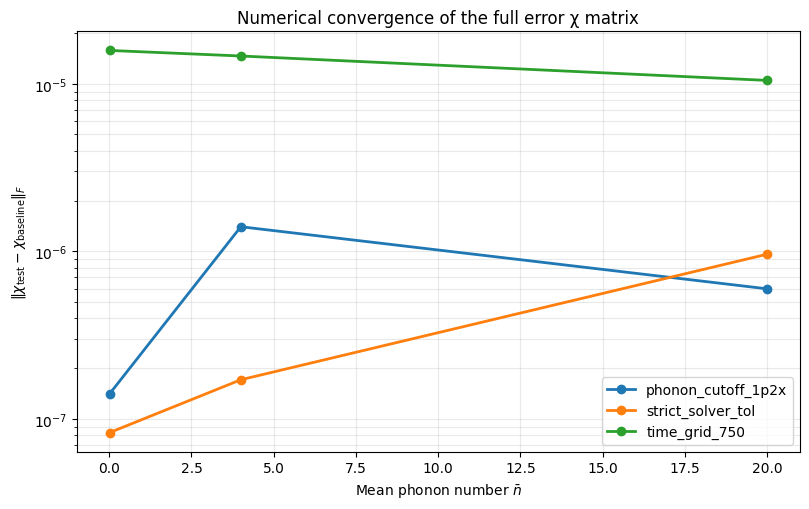

Saved: results/chi_error_element_fit/numerical_convergence/numerical_convergence_summary.csv


In [13]:
CONVERGENCE_CASES = {
    "baseline": {"phonon_scale": 1.0, "time_points": 500, "atol": 1e-12, "rtol": 1e-9},
    "phonon_cutoff_1p2x": {"phonon_scale": 1.2, "time_points": 500, "atol": 1e-12, "rtol": 1e-9},
    "time_grid_750": {"phonon_scale": 1.0, "time_points": 750, "atol": 1e-12, "rtol": 1e-9},
    "strict_solver_tol": {"phonon_scale": 1.0, "time_points": 500, "atol": 1e-13, "rtol": 1e-10},
}

@contextmanager
def temporary_numerical_controls(forced_phonon_dim, atol, rtol):
    original_estimate_phonon_dim = mg.estimate_phonon_dim
    original_solver_options = mg._solver_options

    def fixed_phonon_dim(n_bar, alpha_max):
        return int(forced_phonon_dim)

    def controlled_solver_options(store_states=True, max_step=None):
        options = {"progress_bar": None, "atol": float(atol), "rtol": float(rtol)}
        if max_step is not None:
            if max_step <= 0:
                raise ValueError("max_step must be positive when provided")
            options["max_step"] = float(max_step)
        if not store_states:
            options.update({"store_final_state": True, "store_states": False})
        return options

    mg.estimate_phonon_dim = fixed_phonon_dim
    mg._solver_options = controlled_solver_options
    try:
        yield
    finally:
        mg.estimate_phonon_dim = original_estimate_phonon_dim
        mg._solver_options = original_solver_options

def baseline_phonon_dim(n_bar):
    alpha_max = mg._estimate_alpha_max(
        SIMULATION_PARAMS["A"],
        SIMULATION_PARAMS["delta"],
        SIMULATION_PARAMS["laser_intensity_fluctuation"],
        SIMULATION_PARAMS["laser_detuning_fluctuation"],
    )
    return int(mg.estimate_phonon_dim(float(n_bar), alpha_max))

def convergence_cache_path(case_name, n_bar):
    return CONVERGENCE_DIR / f"{case_name}__nbar_{_safe_nbar_stem(n_bar)}.npz"

def run_convergence_point(case_name, case, n_bar):
    base_dim = baseline_phonon_dim(n_bar)
    forced_dim = max(2, int(np.ceil(base_dim * case["phonon_scale"])))
    overrides = {
        "time_points": int(case["time_points"]),
        "parallel_workers": 1,
        "show_progress": False,
    }
    with temporary_numerical_controls(forced_dim, case["atol"], case["rtol"]):
        chi_raw, chi, metadata = calculate_error_channel_point(n_bar, overrides)
    metadata.update({
        "case": case_name,
        "baseline_phonon_dim": base_dim,
        "forced_phonon_dim": forced_dim,
        "time_points": int(case["time_points"]),
        "solver_atol": float(case["atol"]),
        "solver_rtol": float(case["rtol"]),
    })
    path = convergence_cache_path(case_name, n_bar)
    temporary_path = path.with_name(path.stem + ".tmp.npz")
    np.savez_compressed(
        temporary_path,
        n_bar=float(n_bar),
        case=case_name,
        chi_trace_normalized=chi,
        metadata_json=json.dumps(metadata, default=str),
    )
    temporary_path.replace(path)
    return path

if RUN_NUMERICAL_CONVERGENCE:
    total_jobs = len(CONVERGENCE_NBARS) * len(CONVERGENCE_CASES)
    job_index = 0
    for n_bar in CONVERGENCE_NBARS:
        for case_name, case in CONVERGENCE_CASES.items():
            job_index += 1
            path = convergence_cache_path(case_name, n_bar)
            if path.exists() and not FORCE_RECOMPUTE_PUBLICATION_CACHE:
                print(f"[{job_index:02d}/{total_jobs}] {case_name}, n_bar={n_bar:g}: cached")
                continue
            print(f"[{job_index:02d}/{total_jobs}] {case_name}, n_bar={n_bar:g}: simulating")
            run_convergence_point(case_name, case, n_bar)

convergence_records = []
for n_bar in CONVERGENCE_NBARS:
    loaded = {}
    for case_name in CONVERGENCE_CASES:
        path = convergence_cache_path(case_name, n_bar)
        if path.exists():
            with np.load(path, allow_pickle=False) as data:
                loaded[case_name] = {
                    "chi": np.asarray(data["chi_trace_normalized"], dtype=complex),
                    "metadata": json.loads(str(data["metadata_json"])),
                }
    if "baseline" not in loaded:
        continue
    baseline_chi = loaded["baseline"]["chi"]
    for case_name, result in loaded.items():
        chi = result["chi"]
        metadata = result["metadata"]
        convergence_records.append({
            "n_bar": float(n_bar),
            "case": case_name,
            "phonon_dim": metadata["forced_phonon_dim"],
            "time_points": metadata["time_points"],
            "solver_atol": metadata["solver_atol"],
            "solver_rtol": metadata["solver_rtol"],
            "chi_frobenius_difference_from_baseline": float(np.linalg.norm(chi - baseline_chi)),
            "delta_chi_XX_XX": float(np.real(chi[XX_INDEX, XX_INDEX] - baseline_chi[XX_INDEX, XX_INDEX])),
            "delta_abs_chi_II_XX": float(abs(chi[II_INDEX, XX_INDEX]) - abs(baseline_chi[II_INDEX, XX_INDEX])),
            "delta_chi_IX_IX": float(np.real(chi[PAULI_LABELS.index("IX"), PAULI_LABELS.index("IX")] - baseline_chi[PAULI_LABELS.index("IX"), PAULI_LABELS.index("IX")])),
            "delta_chi_XI_XI": float(np.real(chi[PAULI_LABELS.index("XI"), PAULI_LABELS.index("XI")] - baseline_chi[PAULI_LABELS.index("XI"), PAULI_LABELS.index("XI")])),
        })

convergence_df = pd.DataFrame(convergence_records)
if convergence_df.empty:
    print("Numerical-convergence cache is empty. Set RUN_NUMERICAL_CONVERGENCE=True to calculate it.")
else:
    convergence_csv = CONVERGENCE_DIR / "numerical_convergence_summary.csv"
    convergence_df.to_csv(convergence_csv, index=False)
    display(convergence_df)

    plot_df = convergence_df[convergence_df["case"] != "baseline"]
    fig_conv, ax_conv = plt.subplots(figsize=(8.2, 5.2))
    for case_name, group in plot_df.groupby("case"):
        ax_conv.semilogy(
            group["n_bar"],
            np.maximum(group["chi_frobenius_difference_from_baseline"], 1e-18),
            marker="o",
            linewidth=2,
            label=case_name,
        )
    ax_conv.set_xlabel(r"Mean phonon number $\bar n$")
    ax_conv.set_ylabel(r"$\|\chi_{\rm test}-\chi_{\rm baseline}\|_F$")
    ax_conv.set_title("Numerical convergence of the full error χ matrix")
    ax_conv.grid(True, which="both", alpha=0.28)
    ax_conv.legend()
    fig_conv.tight_layout()
    conv_png = CONVERGENCE_DIR / "numerical_convergence.png"
    conv_pdf = CONVERGENCE_DIR / "numerical_convergence.pdf"
    fig_conv.savefig(conv_png, dpi=300, bbox_inches="tight")
    fig_conv.savefig(conv_pdf, bbox_inches="tight")
    plt.show()
    print(f"Saved: {convergence_csv}")

### 3. ノイズ源ablation（原因の切り分け）

`all`（全ノイズ）、`none`（独立ノイズなし）、`only`（そのノイズだけ）、`without`（そのノイズだけ除去）を比較します。非線形な相互作用があるため、寄与を単純に足し算とは解釈せず、`all - without` と `only - none` の両方を示します。

`RUN_NOISE_SOURCE_ABLATION=True` で代表5点を計算し、各条件の複素χ行列をNPZへ保存します。

[01/50] all, n_bar=0.01: simulating
[02/50] none, n_bar=0.01: simulating
[03/50] only__motional_heating, n_bar=0.01: simulating
[04/50] without__motional_heating, n_bar=0.01: simulating
[05/50] only__motional_dephasing, n_bar=0.01: simulating
[06/50] without__motional_dephasing, n_bar=0.01: simulating
[07/50] only__spin_dephasing, n_bar=0.01: simulating
[08/50] without__spin_dephasing, n_bar=0.01: simulating
[09/50] only__photon_scattering, n_bar=0.01: simulating
[10/50] without__photon_scattering, n_bar=0.01: simulating
[11/50] all, n_bar=1: simulating
[12/50] none, n_bar=1: simulating
[13/50] only__motional_heating, n_bar=1: simulating
[14/50] without__motional_heating, n_bar=1: simulating
[15/50] only__motional_dephasing, n_bar=1: simulating
[16/50] without__motional_dephasing, n_bar=1: simulating
[17/50] only__spin_dephasing, n_bar=1: simulating
[18/50] without__spin_dephasing, n_bar=1: simulating
[19/50] only__photon_scattering, n_bar=1: simulating
[20/50] without__photon_scatteri

,n_bar,noise_source,observable,leave_one_out_all_minus_without,isolated_only_minus_none
0,0.01,motional_heating,chi_XX_XX,7.957329e-07,5.386332e-07
1,0.01,motional_heating,abs_chi_II_XX,8.271729e-06,4.243323e-06
2,0.01,motional_heating,chi_IX_IX,2.428858e-04,2.434732e-04
3,0.01,motional_heating,chi_XI_XI,2.428943e-04,2.434591e-04
4,0.01,motional_dephasing,chi_XX_XX,1.611454e-04,1.610577e-04
...,...,...,...,...,...
75,20.00,spin_dephasing,chi_XI_XI,-2.253780e-06,-3.397647e-07
76,20.00,photon_scattering,chi_XX_XX,-7.566620e-05,-7.754002e-05
77,20.00,photon_scattering,abs_chi_II_XX,-1.576945e-04,-1.603354e-04
78,20.00,photon_scattering,chi_IX_IX,1.992962e-05,2.428152e-05


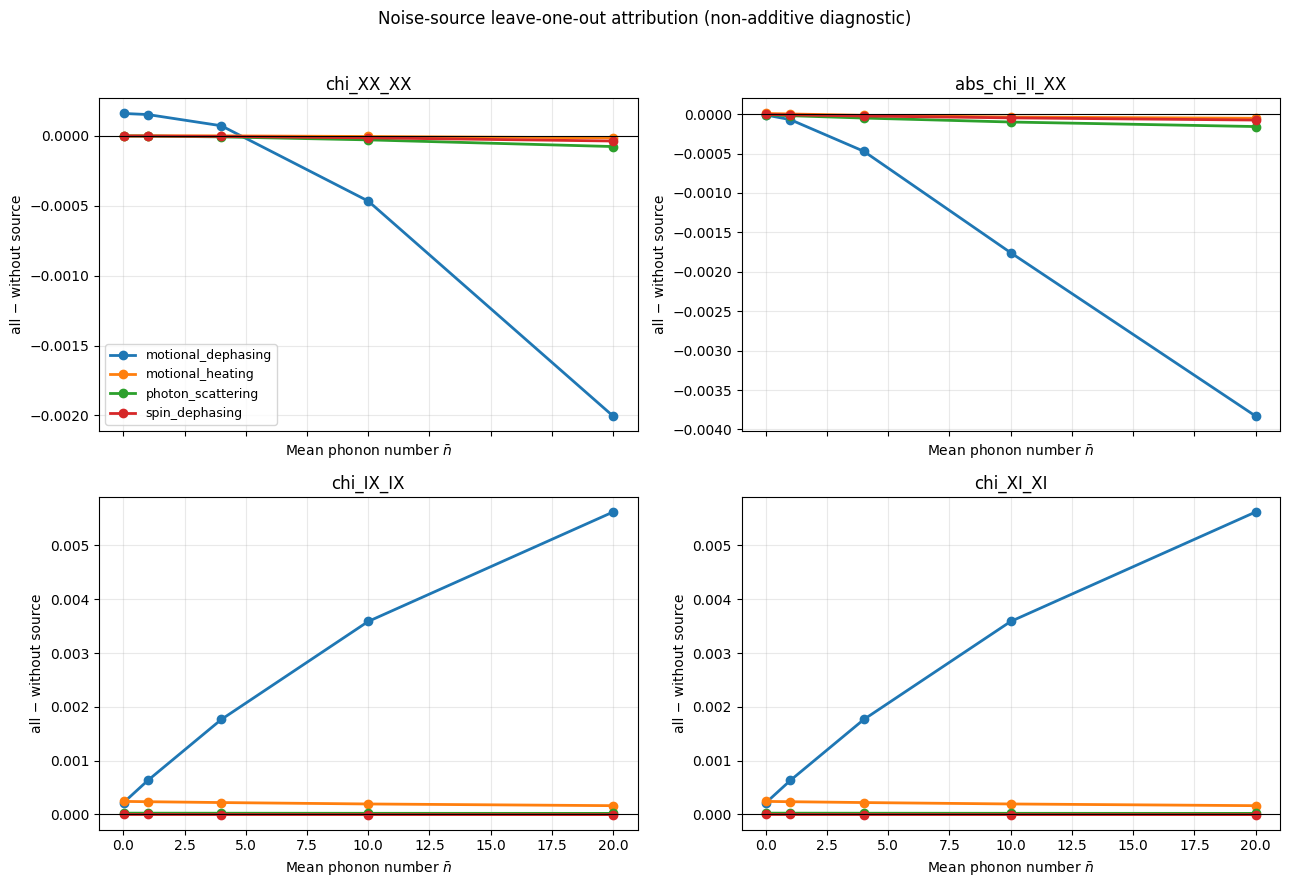

Saved: results/chi_error_element_fit/noise_source_ablation/noise_ablation_attribution.csv


In [14]:
def parameters_with_all_independent_noise_zero(base_parameters):
    params = dict(base_parameters)
    params.update({
        "heating_rate_phys": 0.0,
        "dephasing_rate_phys": 0.0,
        "T2_star": np.inf,
        "rayleigh_rate_phys": 0.0,
        "raman_rate_phys": 0.0,
        "laser_intensity_fluctuation": 0.0,
        "laser_detuning_fluctuation": 0.0,
        "laser_rotation_angle_fluctuation": 0.0,
    })
    return params

def parameters_without_noise_source(base_parameters, noise_source):
    params = dict(base_parameters)
    if noise_source == "motional_heating":
        params["heating_rate_phys"] = 0.0
    elif noise_source == "motional_dephasing":
        params["dephasing_rate_phys"] = 0.0
    elif noise_source == "spin_dephasing":
        params["T2_star"] = np.inf
    elif noise_source == "photon_scattering":
        params["rayleigh_rate_phys"] = 0.0
        params["raman_rate_phys"] = 0.0
    else:
        raise ValueError(f"Unsupported ablation source: {noise_source}")
    return params

def build_ablation_conditions():
    nominal_strengths = mg.nominal_noise_source_strengths(SIMULATION_PARAMS)
    conditions = {
        "all": dict(SIMULATION_PARAMS),
        "none": parameters_with_all_independent_noise_zero(SIMULATION_PARAMS),
    }
    for source in NOISE_SOURCES:
        conditions[f"only__{source}"] = mg.simulation_parameters_with_single_noise_source(
            base_parameters=SIMULATION_PARAMS,
            noise_source=source,
            strength=nominal_strengths[source],
        )
        conditions[f"without__{source}"] = parameters_without_noise_source(
            SIMULATION_PARAMS, source
        )
    return conditions

def ablation_cache_path(condition_name, n_bar):
    return ABLATION_DIR / f"{condition_name}__nbar_{_safe_nbar_stem(n_bar)}.npz"

ABLATION_CONDITIONS = build_ablation_conditions()
if RUN_NOISE_SOURCE_ABLATION:
    total_jobs = len(ABLATION_NBARS) * len(ABLATION_CONDITIONS)
    job_index = 0
    for n_bar in ABLATION_NBARS:
        for condition_name, condition_params in ABLATION_CONDITIONS.items():
            job_index += 1
            path = ablation_cache_path(condition_name, n_bar)
            if path.exists() and not FORCE_RECOMPUTE_PUBLICATION_CACHE:
                print(f"[{job_index:02d}/{total_jobs}] {condition_name}, n_bar={n_bar:g}: cached")
                continue
            print(f"[{job_index:02d}/{total_jobs}] {condition_name}, n_bar={n_bar:g}: simulating")
            overrides = dict(condition_params)
            overrides.update({"parallel_workers": 1, "show_progress": False})
            _, chi, metadata = calculate_error_channel_point(n_bar, overrides)
            metadata.update({"condition": condition_name})
            temporary_path = path.with_name(path.stem + ".tmp.npz")
            np.savez_compressed(
                temporary_path,
                n_bar=float(n_bar),
                condition=condition_name,
                chi_trace_normalized=chi,
                metadata_json=json.dumps(metadata, default=str),
            )
            temporary_path.replace(path)

def ablation_observables(chi):
    ix = PAULI_LABELS.index("IX")
    xi = PAULI_LABELS.index("XI")
    return {
        "chi_XX_XX": float(np.real(chi[XX_INDEX, XX_INDEX])),
        "abs_chi_II_XX": float(abs(chi[II_INDEX, XX_INDEX])),
        "chi_IX_IX": float(np.real(chi[ix, ix])),
        "chi_XI_XI": float(np.real(chi[xi, xi])),
    }

ablation_raw_rows = []
ablation_values = {}
for n_bar in ABLATION_NBARS:
    for condition_name in ABLATION_CONDITIONS:
        path = ablation_cache_path(condition_name, n_bar)
        if not path.exists():
            continue
        with np.load(path, allow_pickle=False) as data:
            chi = np.asarray(data["chi_trace_normalized"], dtype=complex)
        values = ablation_observables(chi)
        ablation_values[(float(n_bar), condition_name)] = values
        ablation_raw_rows.append({
            "n_bar": float(n_bar), "condition": condition_name, **values
        })

ablation_raw_df = pd.DataFrame(ablation_raw_rows)
ablation_attribution_rows = []
for n_bar in ABLATION_NBARS:
    all_values = ablation_values.get((float(n_bar), "all"))
    none_values = ablation_values.get((float(n_bar), "none"))
    if all_values is None or none_values is None:
        continue
    for source in NOISE_SOURCES:
        only_values = ablation_values.get((float(n_bar), f"only__{source}"))
        without_values = ablation_values.get((float(n_bar), f"without__{source}"))
        if only_values is None or without_values is None:
            continue
        for observable in all_values:
            ablation_attribution_rows.append({
                "n_bar": float(n_bar),
                "noise_source": source,
                "observable": observable,
                "leave_one_out_all_minus_without": all_values[observable] - without_values[observable],
                "isolated_only_minus_none": only_values[observable] - none_values[observable],
            })

ablation_attribution_df = pd.DataFrame(ablation_attribution_rows)
if ablation_attribution_df.empty:
    print("Noise-ablation cache is empty. Set RUN_NOISE_SOURCE_ABLATION=True to calculate it.")
else:
    raw_path = ABLATION_DIR / "noise_ablation_raw_observables.csv"
    attribution_path = ABLATION_DIR / "noise_ablation_attribution.csv"
    ablation_raw_df.to_csv(raw_path, index=False)
    ablation_attribution_df.to_csv(attribution_path, index=False)
    display(ablation_attribution_df)

    observable_order = ["chi_XX_XX", "abs_chi_II_XX", "chi_IX_IX", "chi_XI_XI"]
    fig_ablation, axes_ablation = plt.subplots(2, 2, figsize=(13.0, 9.0), sharex=True)
    for ax, observable in zip(axes_ablation.ravel(), observable_order):
        panel = ablation_attribution_df[ablation_attribution_df["observable"] == observable]
        for source, group in panel.groupby("noise_source"):
            ax.plot(
                group["n_bar"], group["leave_one_out_all_minus_without"],
                marker="o", linewidth=2, label=source,
            )
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set_title(observable)
        ax.set_xlabel(r"Mean phonon number $\bar n$")
        ax.set_ylabel("all − without source")
        ax.grid(True, alpha=0.28)
    axes_ablation[0, 0].legend(fontsize=9)
    fig_ablation.suptitle("Noise-source leave-one-out attribution (non-additive diagnostic)")
    fig_ablation.tight_layout(rect=(0, 0, 1, 0.96))
    ablation_png = ABLATION_DIR / "noise_ablation_leave_one_out.png"
    ablation_pdf = ABLATION_DIR / "noise_ablation_leave_one_out.pdf"
    fig_ablation.savefig(ablation_png, dpi=300, bbox_inches="tight")
    fig_ablation.savefig(ablation_pdf, bbox_inches="tight")
    plt.show()
    print(f"Saved: {attribution_path}")

### 4. 全256成分のランキング（見落とし確認）

生の複素χキャッシュから、Hermitian対称な重複を除く上三角136成分（対角16、オフ対角120）を全て比較します。各成分の $\max_{\bar n}|\chi_{P,Q}|$ で順位付けし、上位成分を可視化します。

このセルは「`XI,IX` 以外は小さいのか」を、対角成分だけでなくオフ対角成分も含めて確認するためのものです。

,rank,component,row_pauli,column_pauli,is_diagonal,max_abs_over_sweep,mean_abs_over_sweep
0,1,"II,II",II,II,True,9.975668e-01,9.456226e-01
1,2,"II,XX",II,XX,False,2.252506e-01,1.348869e-01
2,3,"XX,XX",XX,XX,True,1.085955e-01,4.485163e-02
3,4,"IX,IX",IX,IX,True,6.792170e-03,4.271583e-03
4,5,"XI,XI",XI,XI,True,6.792169e-03,4.271585e-03
5,6,"IX,XI",IX,XI,False,6.767138e-03,4.246555e-03
6,7,"IZ,IZ",IZ,IZ,True,1.742226e-04,1.359991e-04
7,8,"ZI,ZI",ZI,ZI,True,1.742221e-04,1.360003e-04
8,9,"YX,YX",YX,YX,True,1.742133e-04,1.359290e-04
9,10,"XY,XY",XY,XY,True,1.742125e-04,1.359305e-04


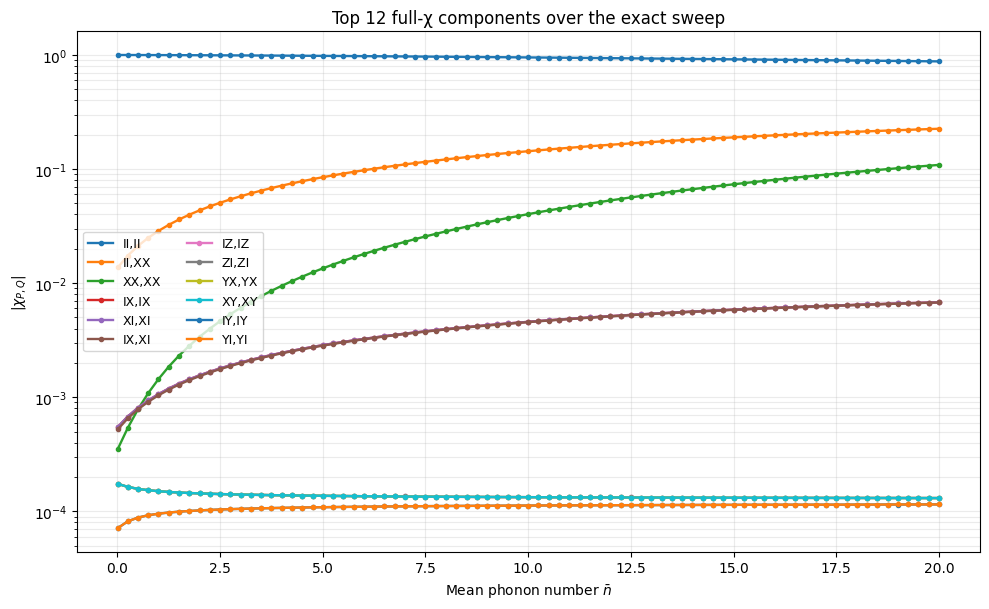

Saved: results/chi_error_element_fit/exact_full_chi/full_chi_component_ranking.csv


In [15]:
full_chi_long_rows = []
for point in exact_full_chi_points:
    chi = point["chi"]
    for row_index, row_label in enumerate(PAULI_LABELS):
        for col_index in range(row_index, len(PAULI_LABELS)):
            col_label = PAULI_LABELS[col_index]
            value = chi[row_index, col_index]
            full_chi_long_rows.append({
                "n_bar": point["n_bar"],
                "row_pauli": row_label,
                "column_pauli": col_label,
                "component": f"{row_label},{col_label}",
                "is_diagonal": row_index == col_index,
                "real": float(np.real(value)),
                "imag": float(np.imag(value)),
                "abs": float(abs(value)),
            })

full_chi_long_df = pd.DataFrame(full_chi_long_rows)
if full_chi_long_df.empty:
    full_chi_ranking_df = pd.DataFrame()
    print("Exact full-chi cache is empty. Run section 1 first to rank all 256 matrix entries.")
else:
    full_chi_long_path = EXACT_FULL_CHI_DIR / "full_chi_components_long.csv"
    full_chi_long_df.to_csv(full_chi_long_path, index=False)
    full_chi_ranking_df = (
        full_chi_long_df.groupby(
            ["component", "row_pauli", "column_pauli", "is_diagonal"], as_index=False
        )
        .agg(max_abs_over_sweep=("abs", "max"), mean_abs_over_sweep=("abs", "mean"))
        .sort_values("max_abs_over_sweep", ascending=False)
        .reset_index(drop=True)
    )
    full_chi_ranking_df.insert(0, "rank", np.arange(1, len(full_chi_ranking_df) + 1))
    full_chi_ranking_path = EXACT_FULL_CHI_DIR / "full_chi_component_ranking.csv"
    full_chi_ranking_df.to_csv(full_chi_ranking_path, index=False)
    display(full_chi_ranking_df.head(25))

    top_components = full_chi_ranking_df.head(FULL_CHI_TOP_K)["component"].tolist()
    fig_rank, ax_rank = plt.subplots(figsize=(10.0, 6.2))
    for component in top_components:
        group = full_chi_long_df[full_chi_long_df["component"] == component].sort_values("n_bar")
        ax_rank.semilogy(
            group["n_bar"], np.maximum(group["abs"], 1e-18),
            marker="o", markersize=3, linewidth=1.7, label=component,
        )
    ax_rank.set_xlabel(r"Mean phonon number $\bar n$")
    ax_rank.set_ylabel(r"$|\chi_{P,Q}|$")
    ax_rank.set_title(f"Top {FULL_CHI_TOP_K} full-χ components over the exact sweep")
    ax_rank.grid(True, which="both", alpha=0.25)
    ax_rank.legend(ncol=2, fontsize=9)
    fig_rank.tight_layout()
    rank_png = EXACT_FULL_CHI_DIR / "full_chi_top_components.png"
    rank_pdf = EXACT_FULL_CHI_DIR / "full_chi_top_components.pdf"
    fig_rank.savefig(rank_png, dpi=300, bbox_inches="tight")
    fig_rank.savefig(rank_pdf, bbox_inches="tight")
    plt.show()
    print(f"Saved: {full_chi_ranking_path}")

### 5. fitモデル比較・交差検証・bootstrap信頼区間

1〜5次のアンカー付き多項式について、$R^2$ だけでなく AICc、BIC、5-fold CV RMSE を比較します。そのうえで、本文で使う4次式について残差bootstrapによる95%区間を計算します。

注意：この区間は**回帰近似の不確かさ**です。実験誤差や数値打切り誤差ではありません。後者は上の収束性検証で別に評価します。

In [ ]:
MODEL_VALIDATION_TARGETS = {
    "chi_XX_XX": (x_data, sweep_df["chi_XX_XX"].to_numpy(float)),
    "abs_chi_II_XX": (x_data, sweep_df["chi_II_XX_abs"].to_numpy(float)),
    "chi_IX_IX": (other_x_data, pauli_wide_df["IX"].to_numpy(float)),
    "chi_XI_XI": (other_x_data, pauli_wide_df["XI"].to_numpy(float)),
}

def anchored_kfold_rmse(x, y, degree, n_splits=5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(x)
    x, y = x[order], y[order]
    non_anchor_indices = np.arange(1, len(x))
    folds = np.array_split(non_anchor_indices, n_splits)
    squared_errors = []
    for test_indices in folds:
        train_mask = np.ones(len(x), dtype=bool)
        train_mask[test_indices] = False
        train_mask[0] = True
        fit = anchored_polynomial_fit(x[train_mask], y[train_mask], degree)
        predictions = fit["predict"](x[test_indices])
        squared_errors.extend((y[test_indices] - predictions) ** 2)
    return float(np.sqrt(np.mean(squared_errors)))

model_comparison_rows = []
for target, (target_x, target_y) in MODEL_VALIDATION_TARGETS.items():
    for degree in range(1, 6):
        fit = anchored_polynomial_fit(target_x, target_y, degree)
        n_observations = len(target_x)
        parameter_count = degree
        rss = max(float(np.sum(fit["residual"] ** 2)), np.finfo(float).tiny)
        aic = n_observations * np.log(rss / n_observations) + 2 * parameter_count
        aicc = aic + (
            2 * parameter_count * (parameter_count + 1)
            / (n_observations - parameter_count - 1)
        )
        bic = n_observations * np.log(rss / n_observations) + parameter_count * np.log(n_observations)
        model_comparison_rows.append({
            "target": target,
            "degree": degree,
            "R_squared": fit["r_squared"],
            "RMSE": fit["rmse"],
            "max_abs_residual": fit["max_abs_residual"],
            "AICc": float(aicc),
            "BIC": float(bic),
            "CV_RMSE_5fold": anchored_kfold_rmse(target_x, target_y, degree),
            "equation": fit["equation"],
        })

model_comparison_df = pd.DataFrame(model_comparison_rows)
model_comparison_df["best_AICc"] = model_comparison_df.groupby("target")["AICc"].transform("min").eq(model_comparison_df["AICc"])
model_comparison_df["best_CV"] = model_comparison_df.groupby("target")["CV_RMSE_5fold"].transform("min").eq(model_comparison_df["CV_RMSE_5fold"])
model_comparison_path = OUTPUT_DIR / "fit_model_comparison_aicc_bic_cv.csv"
model_comparison_df.to_csv(model_comparison_path, index=False)
display(model_comparison_df)

rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_curve_df = pd.DataFrame({"n_bar": x_dense})
bootstrap_coefficient_rows = []
bootstrap_selected_rows = []
for target, (target_x, target_y) in MODEL_VALIDATION_TARGETS.items():
    base_fit = anchored_polynomial_fit(target_x, target_y, FIT_DEGREE)
    centered_residuals = base_fit["residual"] - np.mean(base_fit["residual"])
    prediction_samples = np.empty((BOOTSTRAP_SAMPLES, len(x_dense)))
    coefficient_samples = np.empty((BOOTSTRAP_SAMPLES, FIT_DEGREE))
    for sample_index in range(BOOTSTRAP_SAMPLES):
        synthetic_y = base_fit["fitted"] + rng.choice(
            centered_residuals, size=len(target_y), replace=True
        )
        synthetic_y[0] = target_y[0]
        sample_fit = anchored_polynomial_fit(target_x, synthetic_y, FIT_DEGREE)
        prediction_samples[sample_index] = sample_fit["predict"](x_dense)
        coefficient_samples[sample_index] = sample_fit["coefficients"]

    lower, upper = np.percentile(prediction_samples, [2.5, 97.5], axis=0)
    bootstrap_curve_df[f"{target}_fit"] = base_fit["predict"](x_dense)
    bootstrap_curve_df[f"{target}_ci95_lower"] = lower
    bootstrap_curve_df[f"{target}_ci95_upper"] = upper
    bootstrap_coefficient_rows.append({
        "target": target,
        "coefficient": "a0_anchor",
        "estimate": base_fit["y0"],
        "ci95_lower": base_fit["y0"],
        "ci95_upper": base_fit["y0"],
    })
    for power, estimate in enumerate(base_fit["coefficients"], start=1):
        coefficient_lower, coefficient_upper = np.percentile(
            coefficient_samples[:, power - 1], [2.5, 97.5]
        )
        bootstrap_coefficient_rows.append({
            "target": target,
            "coefficient": f"a{power}",
            "estimate": float(estimate),
            "ci95_lower": float(coefficient_lower),
            "ci95_upper": float(coefficient_upper),
        })
    chosen_model = model_comparison_df[
        (model_comparison_df["target"] == target)
        & (model_comparison_df["degree"] == FIT_DEGREE)
    ].iloc[0]
    bootstrap_selected_rows.append({
        "target": target,
        "chosen_degree": FIT_DEGREE,
        "equation": base_fit["equation"],
        "R_squared": base_fit["r_squared"],
        "RMSE": base_fit["rmse"],
        "AICc": chosen_model["AICc"],
        "BIC": chosen_model["BIC"],
        "CV_RMSE_5fold": chosen_model["CV_RMSE_5fold"],
        "bootstrap_samples": BOOTSTRAP_SAMPLES,
        "bootstrap_seed": BOOTSTRAP_SEED,
    })

bootstrap_coefficient_df = pd.DataFrame(bootstrap_coefficient_rows)
bootstrap_selected_df = pd.DataFrame(bootstrap_selected_rows)
bootstrap_curve_path = OUTPUT_DIR / "fit_bootstrap_95ci_curves.csv"
bootstrap_coefficient_path = OUTPUT_DIR / "fit_bootstrap_coefficient_95ci.csv"
bootstrap_selected_path = OUTPUT_DIR / "fit_selected_models_publication.csv"
bootstrap_curve_df.to_csv(bootstrap_curve_path, index=False)
bootstrap_coefficient_df.to_csv(bootstrap_coefficient_path, index=False)
bootstrap_selected_df.to_csv(bootstrap_selected_path, index=False)
display(bootstrap_selected_df)
display(bootstrap_coefficient_df)

fig_ci, axes_ci = plt.subplots(2, 2, figsize=(13.0, 9.0))
for ax, (target, (target_x, target_y)) in zip(axes_ci.ravel(), MODEL_VALIDATION_TARGETS.items()):
    ax.scatter(target_x, target_y, s=18, alpha=0.65, label="sweep data", zorder=3)
    ax.plot(x_dense, bootstrap_curve_df[f"{target}_fit"], color="black", linewidth=2, label=f"degree-{FIT_DEGREE} fit")
    ax.fill_between(
        x_dense,
        bootstrap_curve_df[f"{target}_ci95_lower"],
        bootstrap_curve_df[f"{target}_ci95_upper"],
        color="#56B4E9", alpha=0.30, label="residual bootstrap 95% interval",
    )
    ax.set_title(target)
    ax.set_xlabel(r"Mean phonon number $\bar n$")
    ax.set_ylabel("χ component")
    ax.grid(True, alpha=0.28)
    ax.legend(fontsize=8)
fig_ci.suptitle("Anchored polynomial fits with residual-bootstrap intervals")
fig_ci.tight_layout(rect=(0, 0, 1, 0.96))
bootstrap_png = OUTPUT_DIR / "fit_bootstrap_95ci.png"
bootstrap_pdf = OUTPUT_DIR / "fit_bootstrap_95ci.pdf"
fig_ci.savefig(bootstrap_png, dpi=300, bbox_inches="tight")
fig_ci.savefig(bootstrap_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {model_comparison_path}")
print(f"Saved: {bootstrap_selected_path}")

### 6. 再現性manifest

最後に、使用した物理パラメータ、χ規格化、ソフトウェア版、Git状態、キャッシュ充足数をJSONへ固定します。論文用の図を更新した際は、このmanifestも同時に保存してください。

In [ ]:
def json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, float) and not np.isfinite(value):
        return str(value)
    return value

def git_output(arguments):
    try:
        return subprocess.check_output(
            ["git", *arguments], text=True, stderr=subprocess.STDOUT
        ).strip()
    except (subprocess.CalledProcessError, FileNotFoundError) as error:
        return f"unavailable: {error}"

manifest = {
    "generated_at_timezone": pd.Timestamp.now(tz="Asia/Tokyo").isoformat(),
    "notebook": str(Path("chi_error_element_nbar_fit.ipynb").resolve()),
    "simulation_parameters": json_safe(SIMULATION_PARAMS),
    "n_bar_grid": json_safe(NBAR_GRID),
    "error_channel_convention": ERROR_CHANNEL_CONVENTION,
    "chi_normalization": "chi / trace(chi)",
    "pauli_basis_order": PAULI_LABELS,
    "fit": {
        "family": "polynomial anchored at n_bar=0.01",
        "reported_degree": FIT_DEGREE,
        "candidate_degrees": [1, 2, 3, 4, 5],
        "bootstrap_samples": BOOTSTRAP_SAMPLES,
        "bootstrap_seed": BOOTSTRAP_SEED,
    },
    "publication_run_flags": {
        "exact_full_chi_sweep": RUN_EXACT_FULL_CHI_SWEEP,
        "numerical_convergence": RUN_NUMERICAL_CONVERGENCE,
        "noise_source_ablation": RUN_NOISE_SOURCE_ABLATION,
    },
    "cache_status": {
        "target_element_points": int(len(sweep_df)),
        "pauli_diagonal_points": int(len(pauli_wide_df)),
        "exact_full_chi_points": int(len(exact_full_chi_points)),
        "expected_sweep_points": int(len(NBAR_GRID)),
        "numerical_convergence_rows": int(len(convergence_df)),
        "noise_ablation_attribution_rows": int(len(ablation_attribution_df)),
    },
    "software_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "matplotlib": matplotlib.__version__,
        "qutip": qp.__version__,
    },
    "git": {
        "commit": git_output(["rev-parse", "HEAD"]),
        "status_short": git_output(["status", "--short"]),
    },
}
manifest_path = OUTPUT_DIR / "publication_reproducibility_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False, allow_nan=False),
    encoding="utf-8",
)
display(pd.Series(manifest["cache_status"], name="count").to_frame())
print(f"Saved: {manifest_path}")

### 論文用の推奨実行順

1. まず通常実行し、既存データ、fit比較、bootstrap図が再現できることを確認する。
2. `RUN_EXACT_FULL_CHI_SWEEP=True` にして81点の生χを確定する。
3. `RUN_NUMERICAL_CONVERGENCE=True` と `RUN_NOISE_SOURCE_ABLATION=True` を順に実行する。
4. 重い計算が完了したら各フラグを `False` に戻し、ノート全体を再実行して全ランキング・図・manifestを固定する。

キャッシュがあるため、重い計算は途中停止後も続きから再開できます。

## 読み方

- $\chi_{XX,XX}$ はPauli twirl後にも残る確率的な `XX` エラー成分です。
- $\chi_{II,XX}$ は `II` と `XX` のコヒーレント結合で、Pauli twirlでは捨てられるオフ対角成分です。
- 二つを並べることで、温度上昇に伴う確率的エラーとコヒーレントエラーの増加を同時に比較できます。
- その他の主要対角成分として `IX` と `XI` が選ばれ、両イオンの単一量子ビット $X$ エラーがほぼ対称に増えることが分かります。
- フィット次数を変更する場合は、上の1〜5次比較表と物理的解釈の両方を確認してください。